In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np


from sklearn.decomposition import PCA

import seaborn as sns
from sklearn.manifold import TSNE

import lissa as li

In [ ]:
def FilterProcedure(entireData: pd.DataFrame, pump: str, windowSize: int)->pd.DataFrame:

    '''
    For each pump, for selected numerical properties, a low frequency filter is passed, trying to reduce the noise into the data. 

    '''

    exportData = (entireData.loc[entireData["Well Run"] == pump].copy()) #copies the original dataset

    Headers = [
    #'ESP discharge temperature sensor',
    'ESP motor temperature',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'ESP Current Module',
    #'ESP Vibration Module',
    #'ESP Power',
    "ESP Vibration X",
    "ESP Vibration Y",
    "POT intake","POT Well Head",
    'Water Cut @ 20degC - 1 atm'
    ]

    Filter = exportData.groupby("Well_down")[Headers].apply(lambda x: (x.ewm(span=24*windowSize).mean()-x.expanding().median())/x.expanding().std())

    # Measure = exportData.groupby("Well_down")[Headers].apply(lambda x: (x.ewm(span=24*windowSize).mean()-x.expanding().median()))
    # MAD = Measure.groupby("Well_down")[Headers].apply(lambda x: x.abs().expanding().median())

    # Filter = SeriesBack(Measure)/SeriesBack(MAD)

    
    Filter = (Filter
        .reset_index()
        .set_index("time")
        .fillna(0)
        .sort_index()
        .drop(columns="Well_down")
    )

   
    removedHeaders = [
    'Water Cut @ 20degC - 1 atm',
    'Choke Opening',
    "Well aligned to Train A",
    "Well aligned to Train B",
    'Failure Info',
    'Pump Info',
    "Well Run",
    "Failure",
    "Well_down"
    
    ]


    return pd.merge(Filter,exportData[removedHeaders],how="left",on="time")


def ProcessData(pumpList: list ,entireData: pd.DataFrame ,windowSize=1,totalDataPath="/")->pd.DataFrame:
    '''

    Apply filter to all pumps and export the resulting dataset.
    
    '''
    totalData = pd.DataFrame(columns=list(entireData))

    for pump in pumpList:
        totalData = pd.concat([totalData,
                            FilterProcedure(entireData, pump,windowSize)
                            ],axis=0)

    totalData.reset_index(inplace=True)
    #totalData.to_csv(totalDataPath)
    totalData.set_index("index",inplace=True)
    
    return totalData



In [ ]:
# entireData = pd.read_csv("../data/totalProcessedData.csv")
# entireData.drop(columns="Unnamed: 0",inplace=True)

baseData = li.DataPreparer("../data","full_sensor_1h [old].csv")

entireData,pumpList = li.FailureMerge(baseData,"../data","respostas.csv")

entireData["ESP Current Module"] = (
    entireData["ESP motor Current - phase A"].pow(2)+
    entireData["ESP motor Current - phase B"].pow(2)+
    entireData["ESP motor Current - phase C"].pow(2)).pow(1/2)


entireData["Choke Opening"] = entireData["Choke Opening"]/100
entireData["Water Cut @ 20degC - 1 atm"] = entireData["Water Cut @ 20degC - 1 atm"]/100

# entireData["POT Well Head"] = (entireData["Well head pressure"]/(entireData["Well head Temperature"]+273)).fillna(0)
# entireData["POT Intake"] = (entireData["ESP intake Pressure"]/(entireData["ESP intake temperature"]+273)).fillna(0)
# entireData["POT Discharge"] = entireData["ESP discharge pressure"]/(entireData["ESP discharge temperature sensor"]+273)

Temperature = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    #'ESP motor temperature',
    'Well head Temperature'
    ]

Pressure = [
    'ESP intake Pressure',
    #'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure'
    ]

Electrical = [
    'ESP Current Module',
    'VSD power frequency',
    'ESP Motor Voltage'
]

Vibration = [
    "ESP Vibration X",
    "ESP Vibration Y"
]

Other = [
    'Choke Opening',
    'Water Cut @ 20degC - 1 atm'
]

POT = pd.DataFrame(entireData[Pressure].fillna(0).to_numpy()/(entireData[Temperature].fillna(25)+273).to_numpy(),columns=["POT intake","POT Well Head"],index=entireData.index)
entireData = pd.concat([entireData,POT],axis=1)

entireData.drop(columns=[
    # "Current Mean",
    "ESP motor Current - phase A",
    "ESP motor Current - phase B",
    "ESP motor Current - phase C",
    # "ESP Vibration X",
    # "ESP Vibration Y",
    # "ESP Motor Voltage",
    'ESP differential pressure', #we are going to try to find this in PCA
    "Well head pressure",
    "ESP intake Pressure",
    # "ESP discharge pressure",
    "Well head Temperature",
    "ESP intake temperature",
    "ESP discharge temperature sensor" #there's too many few entries to be considered.
    ])





totalData = ProcessData(pumpList,entireData,totalDataPath="../data/totalProcessedData_teste.csv")

número de bombas: 38
número de runs: 57


/tmp/ipykernel_366009/3506219440.py:69: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  totalData = pd.concat([totalData,
/tmp/ipykernel_366009/3506219440.py:69: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  totalData = pd.concat([totalData,


<Axes: xlabel='index'>

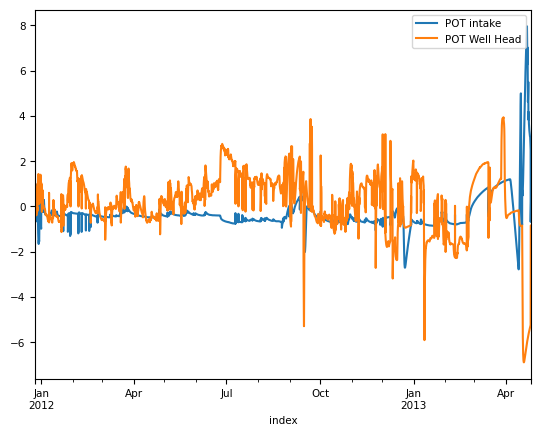

In [19]:
totalData.loc[totalData["Well Run"]==pumpList[0],["POT intake","POT Well Head"]].plot()

array([[<Axes: title={'center': 'ESP motor temperature'}>,
        <Axes: title={'center': 'ESP discharge pressure'}>,
        <Axes: title={'center': 'VSD power frequency'}>],
       [<Axes: title={'center': 'ESP Motor Voltage'}>,
        <Axes: title={'center': 'Current Mean'}>,
        <Axes: title={'center': 'ESP Vibration X'}>],
       [<Axes: title={'center': 'ESP Vibration Y'}>,
        <Axes: title={'center': 'POT intake'}>,
        <Axes: title={'center': 'POT Well Head'}>]], dtype=object)

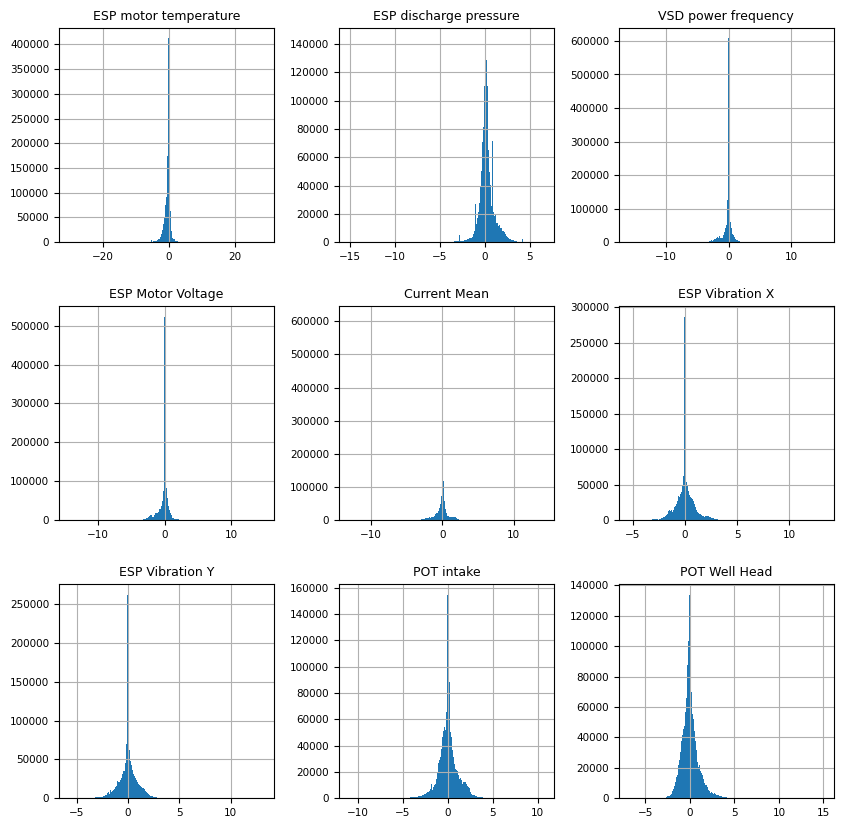

In [ ]:
Headers = [
    #'ESP discharge temperature sensor',
    'ESP motor temperature',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'ESP Current Module',
    #'ESP Vibration Module',
    #'ESP Power',
    "ESP Vibration X",
    "ESP Vibration Y",
    "POT intake","POT Well Head"#,'Water Cut @ 20degC - 1 atm'
    ]


totalData[Headers].hist(bins=200,figsize=(10,10))

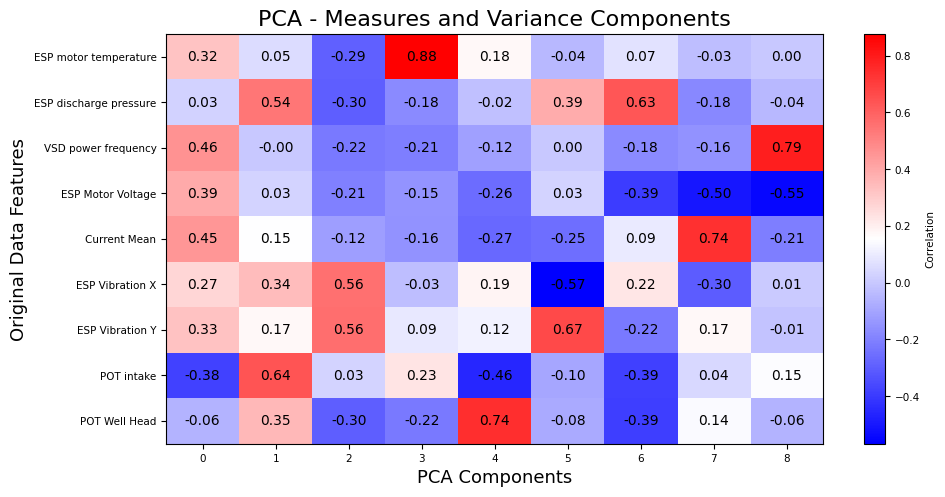

[0.32441749 0.504406   0.6487898  0.74654809 0.83865084 0.89427532
 0.94492004 0.98644696 1.        ]


In [23]:

n = 9

comp = Headers

inputData = totalData[comp].loc[totalData["Well_down"]==0].fillna(0)
pca = PCA(n_components=n)
pca.fit(inputData)

li.FigureComponents(pca,"PCA - Measures and Variance Components",comp)




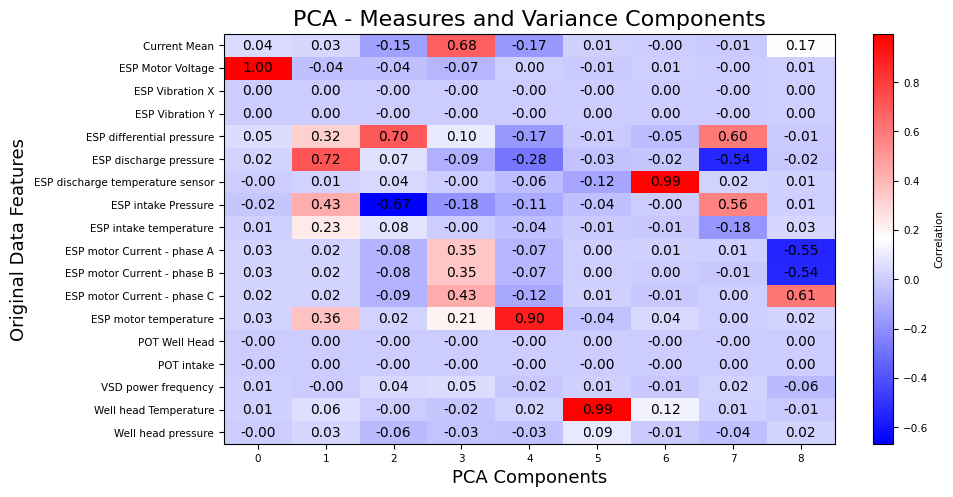

[0.95824755 0.97977245 0.98804319 0.99365049 0.99594849 0.99746878
 0.99869902 0.99934731 0.99961554]


In [24]:
operationalHeaders = li.operationalHeader(entireData)
pca = li.ApplyPCA(entireData, n)
li.FigureComponents(pca,"PCA - Measures and Variance Components",operationalHeaders)
PCAdata = li.ReducePCA(pca, n, operationalHeaders,entireData)


PCAHeaders = [str(i) for i in range(0,n)]
PCAdata = li.ExportPCAData(PCAdata,entireData)
# PCAdata[["Transformed Radius","VibNormX","VibNormY"]] = 0.0
# for pump in pumpList:
#     pumpData = PCAdata.loc[PCAdata["Well Run"]==pump].copy()
#     # PCAdata.loc[pumpData.index,"Transformed Radius"] = li.BoxCoxProccess(pumpData,"Radius")
#     # PCAdata.loc[pumpData.index,"VibNormX"] = li.BoxCoxProccess(pumpData,"ESP Vibration X")
#     # PCAdata.loc[pumpData.index,"VibNormY"] = li.BoxCoxProccess(pumpData,"ESP Vibration Y")

#     fig, axs = li.PCAComponentsPlot(pumpData,pump,PCAHeaders)

#     fig.savefig("imagens/PCAapplied/pump"+pump)
#     plt.close()



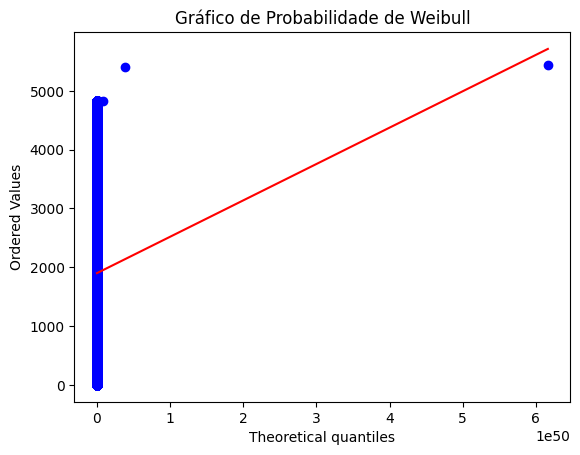

In [8]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

data = PCAdata["Radius"].to_numpy()

# Ajustar os parâmetros da Weibull
shape, loc, scale = stats.weibull_min.fit(data, floc=0)  # Força loc=0 para estabilidade

# Criar o gráfico de probabilidade
fig, ax = plt.subplots()
stats.probplot(data, dist="weibull_min", sparams=(shape,), plot=ax)
plt.title("Gráfico de Probabilidade de Weibull")
plt.show()


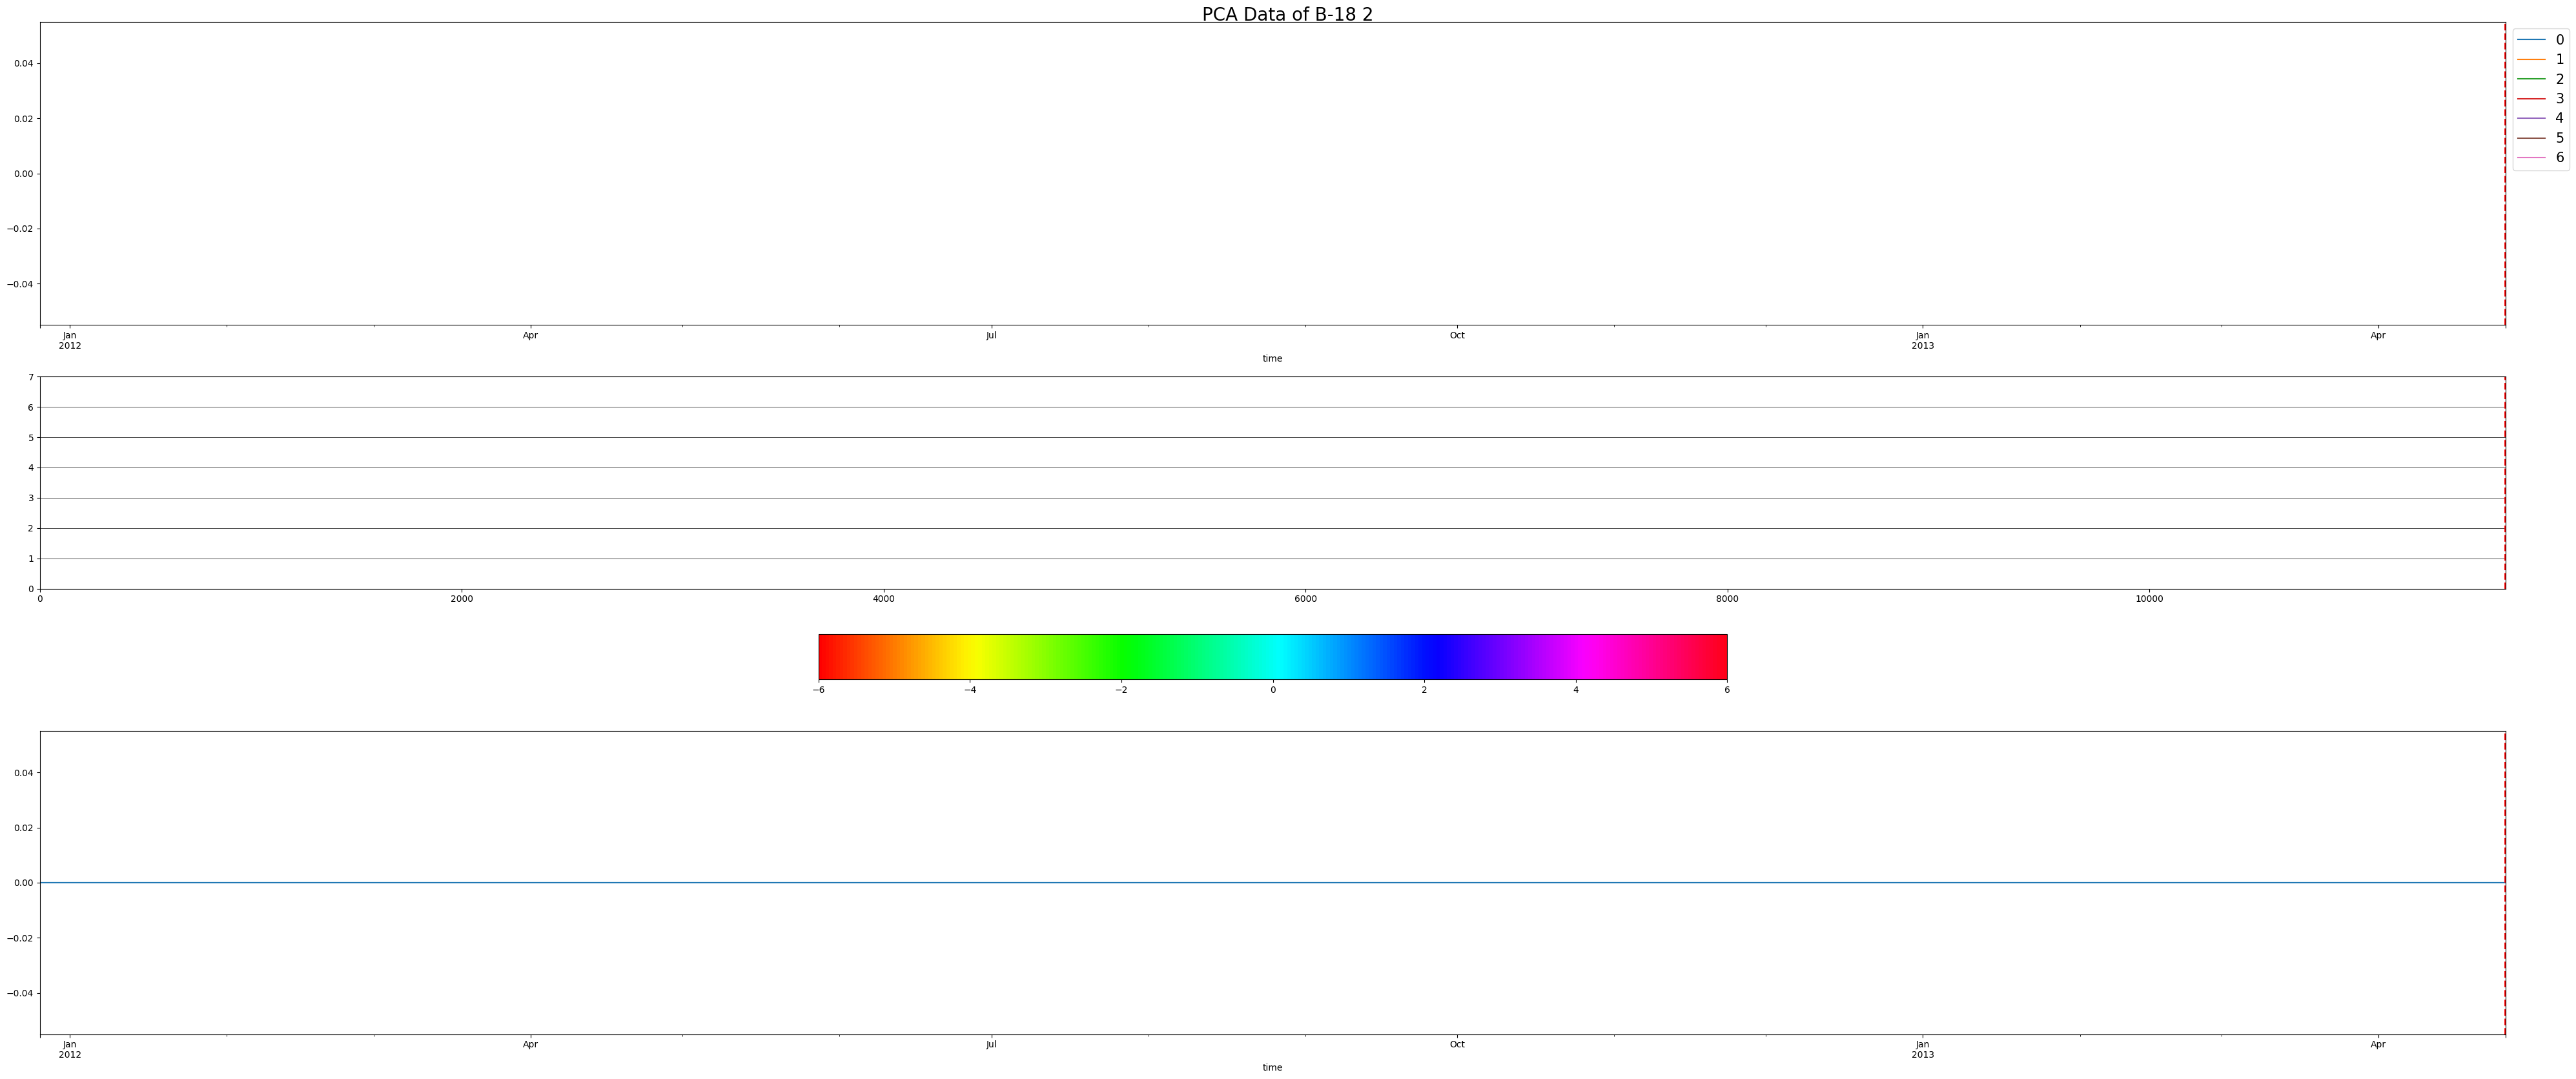

In [9]:
pump = pumpList[0]

# pumpData = PCALF.loc[PCALF["Well Run"]==pump].copy()

# PCAHeaders = [i for i in range(0,componentsLF)]

pumpData = PCAdata.loc[PCAdata["Well Run"]==pump].copy()




li.PCAComponentsPlot(pumpData,pump,PCAHeaders)
plt.tight_layout()

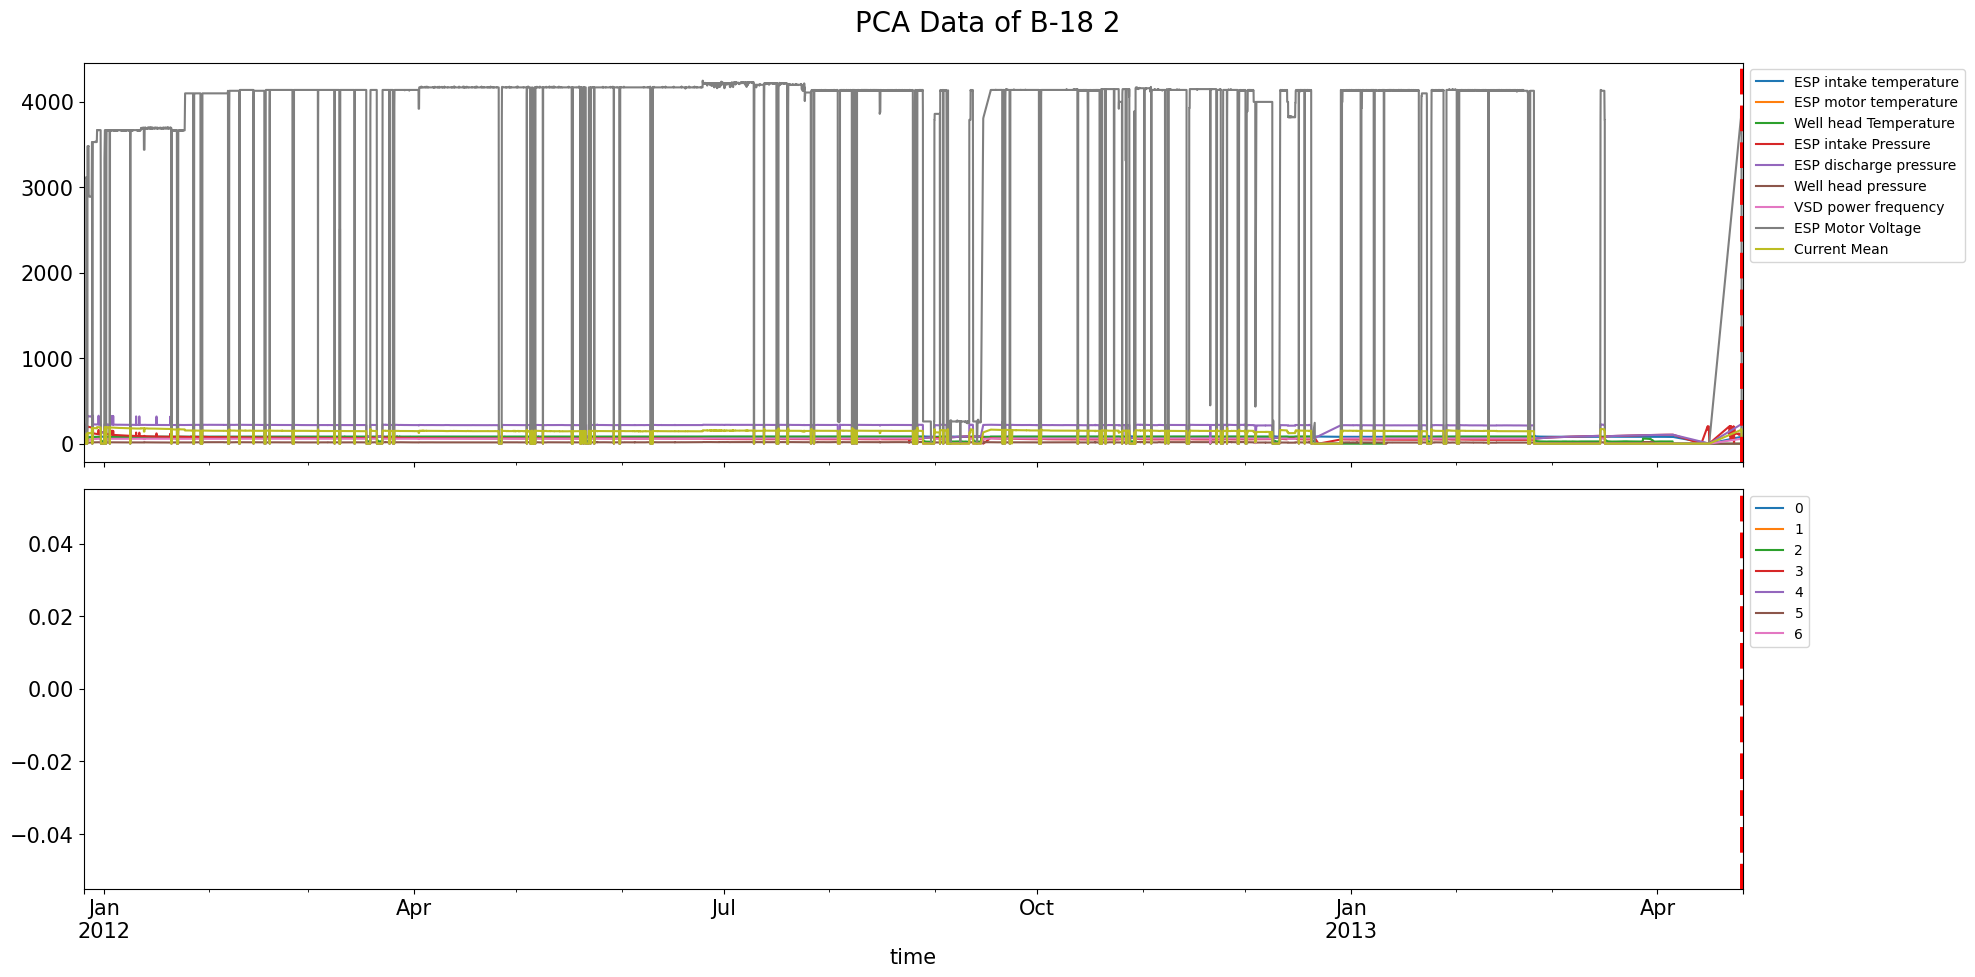

In [ ]:
pumpDataOriginal = entireData.loc[entireData["Well Run"]==pump].copy()

Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'ESP Current Module'
    #'ESP Vibration Module',
    #'ESP Power'
    ]

li.PCAComparisionPlot(pumpData,pumpDataOriginal,pump,PCAHeaders,Headers)
plt.savefig("../imagens_gerais/PCA_b_28_2.jpg")

7.5

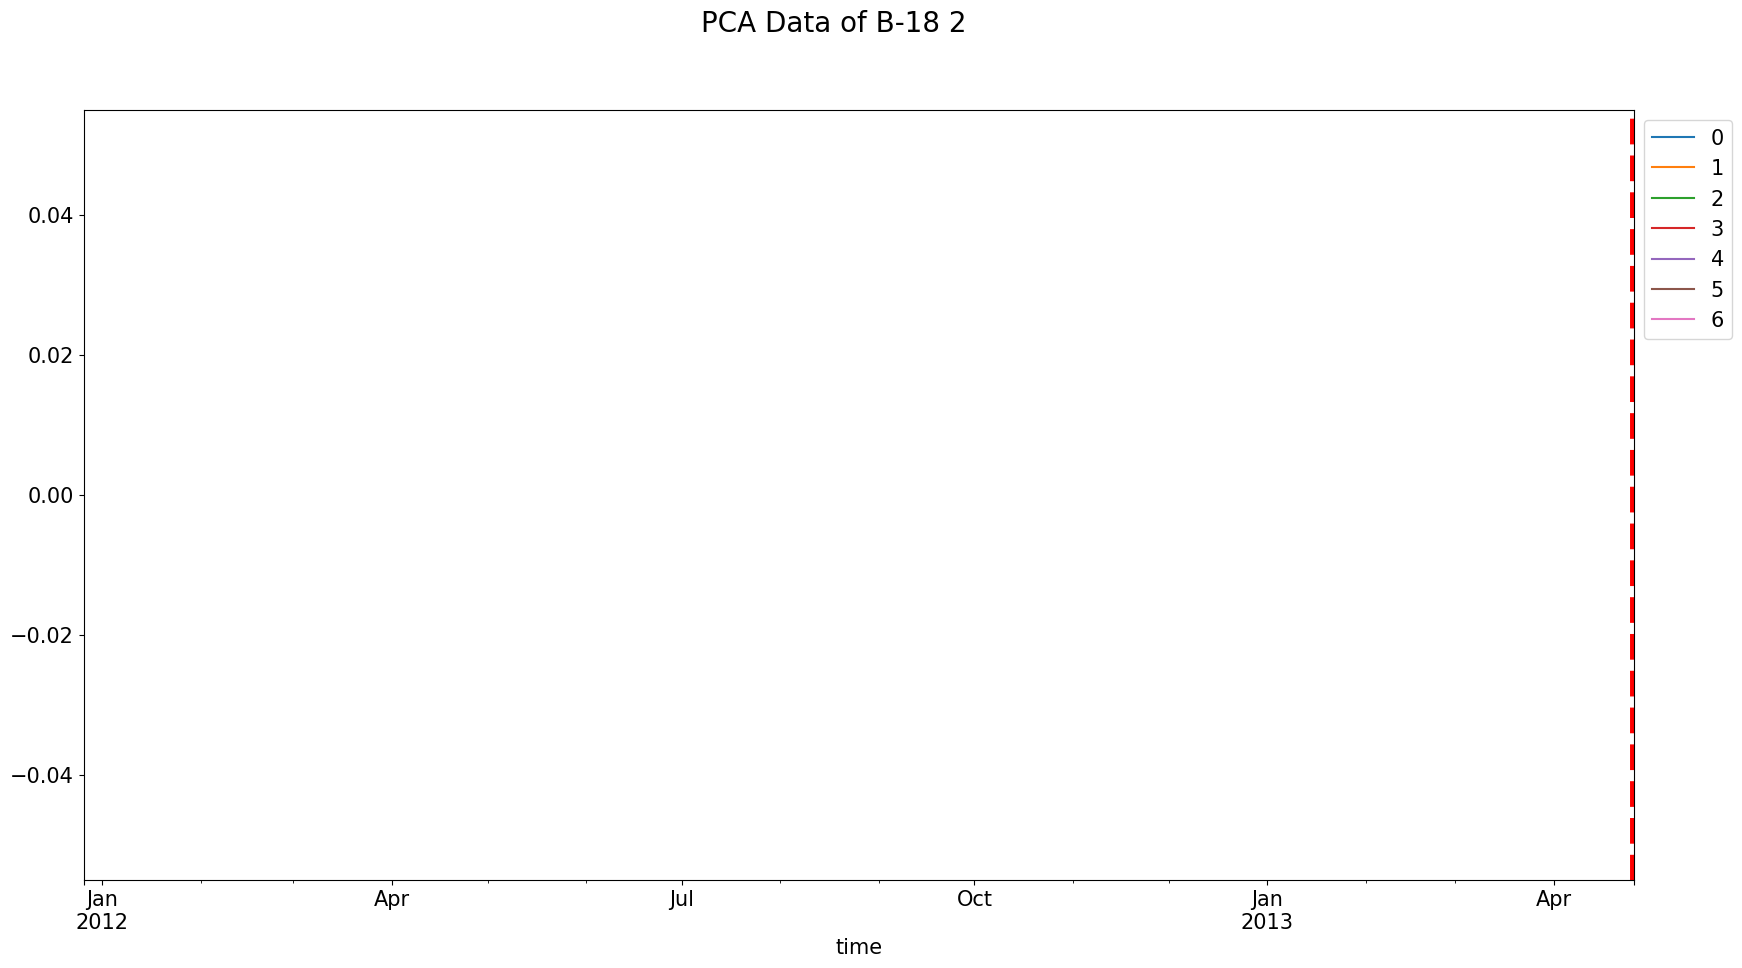

In [11]:
pump = pumpList[0]
plt.rcParams['font.size'] = 15.0

pumpData = PCAdata.loc[PCAdata["Well Run"]==pump].copy()

fig, ax = plt.subplots(1,1, figsize=(20,10))

pumpData[PCAHeaders].plot(ax=ax)

ax.axvline(pumpData.loc[pumpData["Failure"]==True].index[0], color='red', linestyle='--', linewidth=5)
ax.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)

fig.suptitle("PCA Data of " + pump,fontsize=20);


factor = 0.5


plt.rcParams.update({
    'font.size': plt.rcParams['font.size'] * factor,
})

#fig.savefig("imagens/relatorio/PCAapplied")

plt.rcParams['font.size']

In [12]:
import numpy as np
from scipy.stats import chisquare

# Contagens das classes ao longo das inicializações
observed_counts = np.array([20,20,60])  # Substituir pelos valores reais
expected_counts = np.array([1/3, 1/3, 1/3]) * sum(observed_counts)

# Teste qui-quadrado de aderência
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Estatística qui-quadrado: {chi2_stat:.4f}, p-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Rejeitamos H0: C ocorre significativamente mais do que o esperado.")
else:
    print("Não há evidências suficientes para afirmar que C ocorre mais que o esperado.")


Estatística qui-quadrado: 32.0000, p-valor: 0.0000
Rejeitamos H0: C ocorre significativamente mais do que o esperado.
